# Limpeza e tratamento das bases  

## Objetivo do Notebook  
Este notebook tem como objetivo padronizar a preparação e o tratamento das diferentes bases de dados utilizadas no estudo, garantindo consistência entre variáveis, targets e pré-processamento.  
A proposta é aplicar um conjunto de regras claras e reprodutíveis para cada dataset, de forma que os resultados de modelagem e métricas de fairness sejam comparáveis entre si.  

## Datasets  
1. [Default of Credit Card Clients](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)  
2. [Credit Card Approval Prediction](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)  
3. [Credit Card Customers (BankChurners)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers) 
4. [German Credit](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

# Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Funções auxiliares

In [3]:
# =====================
# Tipo de variáveis
# =====================

def listar_variaveis_por_tipo(df):
    # Colunas por tipo (considera também dtypes "nullable" do pandas)
    obj_cols   = df.select_dtypes(include=['object']).columns.tolist()
    cat_cols   = df.select_dtypes(include=['category']).columns.tolist()
    int_cols   = df.select_dtypes(include=['int64', 'int32', 'Int64', 'Int32']).columns.tolist()
    float_cols = df.select_dtypes(include=['float64', 'float32', 'Float64', 'Float32']).columns.tolist()

    # Impressão no formato solicitado
    print("variaveis 'object','category' =", obj_cols + cat_cols)
    print("variaveis 'int64','float64'  =", int_cols + float_cols)

    # (Opcional) retornar um dicionário para uso programático
    return {
        "object_category": obj_cols + cat_cols,
        "int": int_cols,
        "float": float_cols
    }

# =====================
# Analisar variáveis uma a uma
# =====================
def analisar_variavel(df, col):
    print("="*60)
    print(f"📊 Variável: {col}")
    print("Tipo:", df[col].dtype)
    print("Nulos:", df[col].isna().sum())
    print("Valores únicos:", df[col].nunique())
    print("\nTop valores:")
    print(df[col].value_counts(normalize=True).head(10))
    
    if pd.api.types.is_numeric_dtype(df[col]):
        print("\nEstatísticas descritivas:")
        print(df[col].describe())


# =====================
# Analisar distribuição de target e sexo
# =====================

def plot_sex_distribution(df, title):
    # Substituir valores numéricos por rótulos textuais
    df['sensitive_sexo'] = df['sensitive_sexo'].map({1: 'Male', 0: 'Female'})

    # Criar o gráfico de contagem
    ax = sns.countplot(data=df, x='sensitive_sexo', hue='target')

    # Adicionar rótulos de contagem nas barras
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fontsize=8)

    # Títulos e rótulos
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('sensitive_sexo')
    ax.set_ylabel('Count')

    plt.show()

def plot_age_distribution(df, title):
    # Garantir que a coluna é categórica na ordem desejada
    categorias = ["jovem", "adulto", "idoso"]
    df["sensitive_age"] = df["sensitive_age"].astype("category")
    df["sensitive_age"] = df["sensitive_age"].cat.set_categories(categorias, ordered=True)

    # Gráfico
    ax = sns.countplot(data=df, x='sensitive_age', hue='target')

    # Labels nas barras
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fontsize=8)

    # Títulos e rótulos
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('sensitive_age')
    ax.set_ylabel('Count')

    plt.show()



## Dataset 1: Default of Credit Card Clients

Distribuição original da variável target:
 target
0    23364
1     6636
Name: count, dtype: int64
Shape: (29478, 24)

Colunas: ['LIMIT_BAL', 'ordinal_EDUCATION', 'ordinal_PAY_0', 'ordinal_PAY_2', 'ordinal_PAY_3', 'ordinal_PAY_4', 'ordinal_PAY_5', 'ordinal_PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target', 'sensitive_sexo', 'is_marriage', 'sensitive_age']
variaveis 'object','category' = ['sensitive_age']
variaveis 'int64','float64'  = ['ordinal_EDUCATION', 'ordinal_PAY_0', 'ordinal_PAY_2', 'ordinal_PAY_3', 'ordinal_PAY_4', 'ordinal_PAY_5', 'ordinal_PAY_6', 'target', 'sensitive_sexo', 'is_marriage', 'LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
📊 Variável: LIMIT_BAL
Tipo: float64
Nulos: 0
Valores únicos: 81

Top valores:
LIMIT_BAL
50000.0     0.112966
20000.

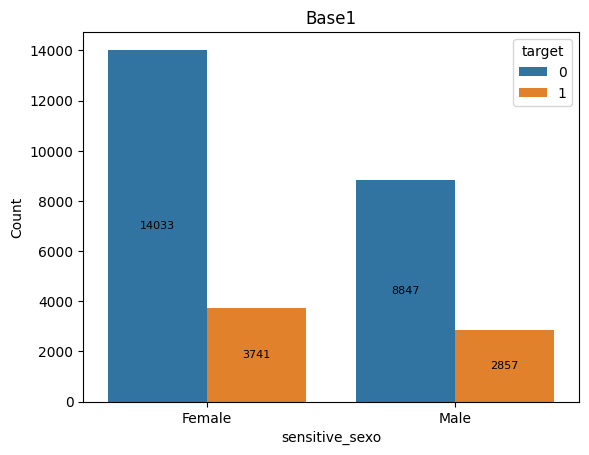

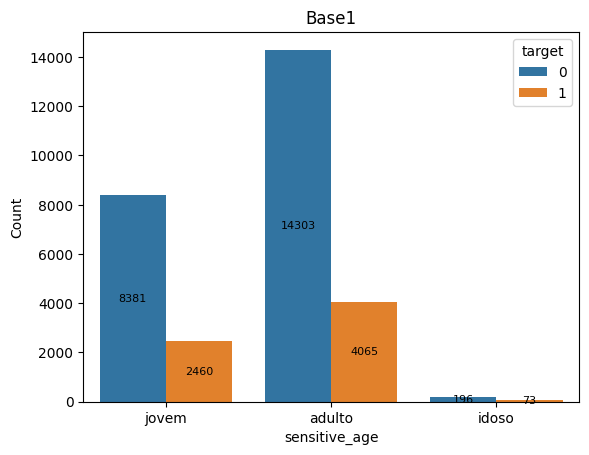

In [ ]:
# =========================
# Configurações de paths
# =========================
raw_path = Path("../datasets/raw/kaggle_credit_card/UCI_Credit_Card.csv")
out_age_path = Path("../datasets/processed/base1_age.csv")
out_sexo_path = Path("../datasets/processed/base1_sexo.csv")

# =========================
# Leitura
# =========================
df = pd.read_csv(raw_path, delimiter=",")

# =========================
# Target: renomear 
# =========================
df.rename(columns={'default.payment.next.month': 'target'}, inplace=True)
classe_counts = df['target'].value_counts()
print("Distribuição original da variável target:\n", classe_counts)

# =========================
# Excluir coluna ID
# =========================
df.drop(columns=['ID'], inplace=True)

# =========================
# SEX -> dummie sensitive_sexo (1=masculino, 0=feminino)
#   - Remover coluna original SEX
#   - dataset original: 1=male, 2=female
# =========================

df['sensitive_sexo'] = np.where(df['SEX'] == 1, 1, 0).astype(int)
df.drop(columns=['SEX'], inplace=True)

# =========================
# MARRIAGE -> dummie is_marriage
#   - Remover registros com MARRIAGE == 0 (indefinidos)
#   - Criar is_marriage: 0 = não casados (2/3), 1 = casados (1)
#   - Remover coluna original MARRIAGE
# =========================
df = df[df['MARRIAGE'] != 0].copy()
df['is_marriage'] = np.where(df['MARRIAGE'] == 1, 1, 0).astype(int)
df.drop(columns=['MARRIAGE'], inplace=True)

# =========================
# EDUCATION
#   - Excluir casos 0,4,5,6 (others/unknown)
#   - Reescrever labels para uma codificação ordinal:
#       0 -> Ensino Médio
#       1 -> Graduação
#       2 -> Pós-graduação
#   Observação: valores originais:
#       1=graduate school, 2=university, 3=high school, 4/5/6/0=others/unknown
#   Para obedecer a regra:
#       3 -> 0 (Ensino Médio)
#       2 -> 1 (Graduação)
#       1 -> 2 (Pós-graduação)
# =========================

df = df[df['EDUCATION'].isin([1, 2, 3])].copy()  # excluir 0,4,5,6
map_edu = {3: 0, 2: 1, 1: 2}
df['EDUCATION'] = df['EDUCATION'].map(map_edu).astype(int)

# =========================
# Variável AGE -> sensitive_age (categórica)
#   - 0-30: jovem
#   - 31-60: adulto
#   - 61+: idoso
#   - Remover AGE numérica original
# =========================

def categorizar_idade(x):
    if x <= 30:
        return "jovem"
    elif x <= 60:
        return "adulto"
    else:
        return "idoso"

df["sensitive_age"] = df["AGE"].apply(categorizar_idade).astype("category")
df.drop(columns=["AGE"], inplace=True)

# =========================
# Variáveis ordinais (manter como estão, sem transformação)
#   PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6
# =========================
variaveis_ordinais = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ,'EDUCATION']
df.rename(columns={col: f"ordinal_{col}" for col in variaveis_ordinais}, inplace=True)
    
# =========================
# Checagens rápidas
# =========================
print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())

listar_variaveis_por_tipo(df)

for col in df.columns:
    analisar_variavel(df, col)

# =========================
# Salvar
# =========================

# Versão 1: com sensitive_age, sem sensitive_sexo
df.drop(columns=["sensitive_sexo"], errors="ignore").to_csv(out_age_path, index=False)

# Versão 2: com sensitive_sexo, sem sensitive_age
df.drop(columns=["sensitive_age"], errors="ignore").to_csv(out_sexo_path, index=False)

# =========================
# Distribuição do target
# =========================

plot_sex_distribution(df, 'Base1')
plot_age_distribution(df, 'Base1')

## Dataset 2: Credit Card Approval Prediction

Removendo 47 duplicatas por ID do demográfico...
Shape: (36457, 16)

Colunas: ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'sensitive_sexo', 'own_car', 'own_realty', 'children_cat', 'ordinal_EDUCATION', 'is_marriage', 'sensitive_age', 'is_unemployed', 'fam_size_cat', 'target']
variaveis 'object','category' = ['NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE', 'children_cat', 'sensitive_age', 'fam_size_cat']
variaveis 'int64','float64'  = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'sensitive_sexo', 'own_car', 'own_realty', 'ordinal_EDUCATION', 'is_marriage', 'is_unemployed', 'target', 'AMT_INCOME_TOTAL']
📊 Variável: AMT_INCOME_TOTAL
Tipo: float64
Nulos: 0
Valores únicos: 265

Top valores:
AMT_INCOME_TOTAL
135000.0    0.118194
180000.0    0.084949
157500.0    0.084730
112500.0    0.081082
225000.0    0.080259
202500.0    0.060126
90000.0     0.048523
270000.0    0.045945
315000.0    0.027457
67500.0     0.023946
Name: proportion,

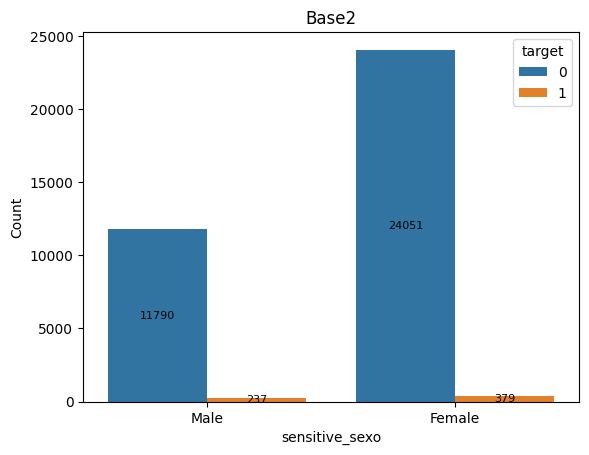

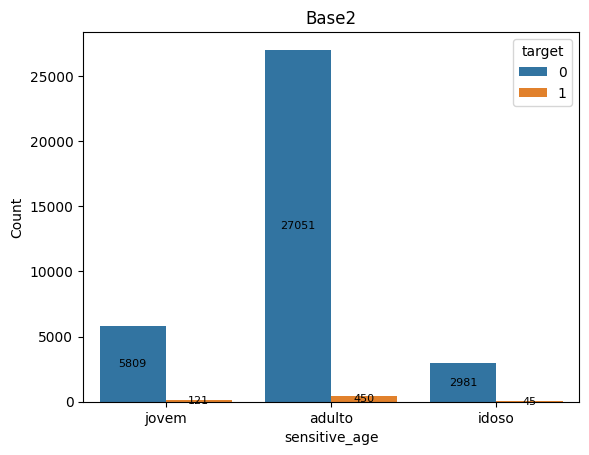

In [5]:
# =========================
# Paths
# =========================

app_path = Path("../datasets/raw/credit_card_approval_prediction/application_record.csv")
cred_path = Path("../datasets/raw/credit_card_approval_prediction/credit_record.csv")
out_age_path = Path("../datasets/processed/base2_age.csv")
out_sexo_path = Path("../datasets/processed/base2_sexo.csv")

# =========================
# 1) Ler app_path e remover duplicatas por ID
# =========================
df_app = pd.read_csv(app_path, encoding="utf-8")

# Remove duplicatas por ID (mantém a 1ª ocorrência)
dup_count = df_app.duplicated(subset=["ID"]).sum()
if dup_count > 0:
    print(f"Removendo {dup_count} duplicatas por ID do demográfico...")
df_app = df_app.drop_duplicates(subset=["ID"], keep="first").copy()

# =========================
# 2) Transformações
# =========================

# --- CODE_GENDER -> is_male (M=1, F=0)
# Observação: alguns datasets trazem 'XNA' ou valores inesperados; mapeamos para NaN.
gender_map = {"M": 1, "F": 0}
df_app["sensitive_sexo"] = df_app["CODE_GENDER"].map(gender_map).astype("Int64")

# --- FLAG_OWN_CAR -> own_car (Y=1, N=0)
df_app["own_car"] = df_app["FLAG_OWN_CAR"].map({"Y": 1, "N": 0}).astype("Int64")

# --- FLAG_OWN_REALTY -> own_realty (Y=1, N=0)
df_app["own_realty"] = df_app["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0}).astype("Int64")

# --- CNT_CHILDREN -> children_cat (0->0, 1->1, >=2->2)
def _children_cat(x):
    try:
        xi = int(x)
    except:
        return "missing"
    if xi <= 0:
        return "no_children"
    elif xi == 1:
        return "one_child"
    else:
        return "two_or_more"

df_app["children_cat"] = df_app["CNT_CHILDREN"].apply(_children_cat).astype("category")

# --- NAME_EDUCATION_TYPE -> education_ordinal (Lower secondary=0 < ... < Academic degree=4)
edu_order = {
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4,
}
# normaliza espaços/caso se necessário
df_app["ordinal_EDUCATION"] = df_app["NAME_EDUCATION_TYPE"].map(edu_order).astype("Int64")

# --- NAME_FAMILY_STATUS -> is_marriage (Married/Civil marriage=1; demais=0)
# normalização simples para robustez
fam = df_app["NAME_FAMILY_STATUS"].astype(str).str.strip().str.lower()
is_marriage = fam.isin(["married", "civil marriage"]).astype(int)
df_app["is_marriage"] = is_marriage.astype("Int64")

# --- DAYS_BIRTH -> age e sensitive_age (idade em anos inteiros)
# (o campo costuma ser negativo; usa-se o valor absoluto)
df_app["age"] = (df_app["DAYS_BIRTH"].abs() // 365).astype("Int64")

# =========================
# Variável AGE -> sensitive_age (categórica)
#   - 0-30: jovem
#   - 31-60: adulto
#   - 61+: idoso
#   - Remover AGE numérica original
# =========================

def categorizar_idade(x):
    if x <= 30:
        return "jovem"
    elif x <= 60:
        return "adulto"
    else:
        return "idoso"

df_app["sensitive_age"] = df_app["age"].apply(categorizar_idade).astype("category")

# --- DAYS_EMPLOYED -> is_unemployed (dummy 1=desempregado/sem emprego, 0=empregado)
# descrição: se DAYS_EMPLOYED >= 0 => desempregado (contagem regressiva a partir de 0)
df_app["is_unemployed"] = (df_app["DAYS_EMPLOYED"] >= 0).astype(int).astype("Int64")

# --- CNT_FAM_MEMBERS -> fam_size_cat (1->1, 2->2, >=3->3)
def _fam_size_cat(x):
    try:
        xf = float(x)
    except:
        return "missing"
    if xf <= 1.0:
        return "single"
    elif xf <= 2.0:
        return "two_members"
    else:
        return "three_or_more"

df_app["fam_size_cat"] = df_app["CNT_FAM_MEMBERS"].apply(_fam_size_cat).astype("category")

# =========================
# Remover colunas originais substituídas por versões padronizadas
# =========================
cols_to_drop = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "CNT_CHILDREN",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS",
    "age",
    "FLAG_MOBIL", #excluindo pq só tem um unico valor em todo dataset
    "OCCUPATION_TYPE" #excluindo pois tem muitos nulos
]
df_app_processed = df_app.drop(columns=[c for c in cols_to_drop if c in df_app.columns]).copy()

# =========================
# 3) Ler CREDIT_RECORD e criar target (1 se algum STATUS >= '2' para o ID)
# =========================
df_cred = pd.read_csv(cred_path, encoding="utf-8")

# STATUS pode ser '0','1','2','3','4','5','C','X'. Queremos saber se houve algum '2','3','4','5'.
# Cria uma flag linha a linha
is_60p = df_cred["STATUS"].astype(str).isin(["2", "3", "4", "5"]).astype(int)

# Agrega por ID: target = 1 se houver ao menos um mês com atraso >= 60 dias
df_target = (
    pd.DataFrame({"ID": df_cred["ID"], "is_60p": is_60p})
    .groupby("ID", as_index=False)["is_60p"]
    .max()
    .rename(columns={"is_60p": "target"})
)

# =========================
# 4) Merge features (processado) + TARGET (inner join)
# =========================
df_final = df_app_processed.merge(df_target, on="ID", how="inner")
df_final.drop(columns=['ID'], inplace=True)

# =========================
# 5) Checagens rápidas
# =========================
print("Shape:", df_final.shape)
print("\nColunas:", df_final.columns.tolist())

listar_variaveis_por_tipo(df_final)

for col in df_final.columns:
    analisar_variavel(df_final, col)

# =========================
# 6) Salvar
# =========================

# Versão 1: com sensitive_age, sem sensitive_sexo
df_final.drop(columns=["sensitive_sexo"], errors="ignore").to_csv(out_age_path, index=False)

# Versão 2: com sensitive_sexo, sem sensitive_age
df_final.drop(columns=["sensitive_age"], errors="ignore").to_csv(out_sexo_path, index=False)

# =========================
# 7) Distribuição do target
# =========================

plot_sex_distribution(df_final, 'Base2')
plot_age_distribution(df_final, 'Base2')

## Dataset 3: Credit Card Customers (BankChurners)

Shape: (10127, 20)

Colunas: ['ordinal_Dependent_count', 'ordinal_Months_on_book', 'ordinal_Total_Relationship_Count', 'ordinal_Months_Inactive_12_mon', 'ordinal_Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'ordinal_Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'target', 'ordinal_EDUCATION', 'ordinal_income_category', 'ordinal_CARD', 'is_marriage', 'sensitive_sexo', 'sensitive_age']
variaveis 'object','category' = ['sensitive_age']
variaveis 'int64','float64'  = ['ordinal_Dependent_count', 'ordinal_Months_on_book', 'ordinal_Total_Relationship_Count', 'ordinal_Months_Inactive_12_mon', 'ordinal_Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Trans_Amt', 'ordinal_Total_Trans_Ct', 'target', 'ordinal_EDUCATION', 'ordinal_income_category', 'ordinal_CARD', 'is_marriage', 'sensitive_sexo', 'Credit_Limit', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Rat

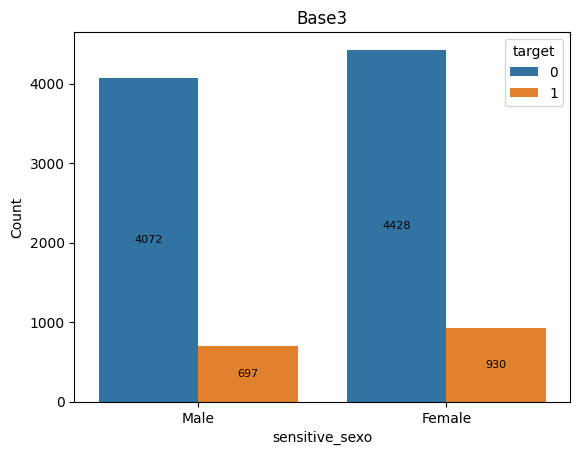

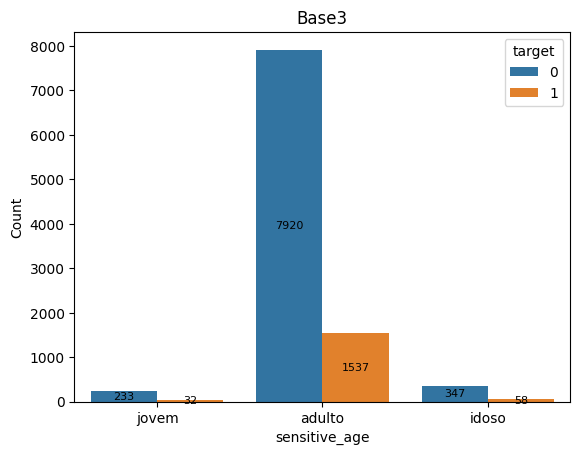

In [6]:
# Configurações de paths
raw_path = Path("../datasets/raw/credit_card_customers/BankChurners.csv")
out_age_path = Path("../datasets/processed/base3_age.csv")
out_sexo_path = Path("../datasets/processed/base3_sexo.csv")

# Leitura
data = pd.read_csv(raw_path)
data = data.iloc[:, :-2]
data = data.drop(columns='CLIENTNUM')

# Cria e transforma variaveis
menor_classe = data['Attrition_Flag'].value_counts().idxmin()
data['target'] = (data['Attrition_Flag'] == menor_classe).astype(int)

# Ordem nivel educacional
education_order = {'Uneducated': 0, 'High School': 1, 'College': 2, 'Graduate': 3, 
                   'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': -1}
data['ordinal_EDUCATION'] = data['Education_Level'].map(education_order)

# Ordem income
income_order = {
    'Less than $40K': 0,
    '$40K - $60K': 1,
    '$60K - $80K': 2,
    '$80K - $120K': 3,
    '$120K +': 4,
    'Unknown': -1
}
data['ordinal_income_category'] = data['Income_Category'].map(income_order)

# Ordem cartao de credito
card_order = {
    'Blue': 0,
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
}
data['ordinal_CARD'] = data['Card_Category'].map(card_order)

# Marital Status
data['is_marriage'] = (data['Marital_Status'] == 'Married').astype('int')

# Sexo
gender_map = {"M": 1, "F": 0}
data["sensitive_sexo"] = data["Gender"].map(gender_map).astype("Int64")

# =========================
# Variável AGE -> sensitive_age (categórica)
#   - 0-30: jovem
#   - 31-60: adulto
#   - 61+: idoso
#   - Remover AGE numérica original
# =========================

def categorizar_idade(x):
    if x <= 30:
        return "jovem"
    elif x <= 60:
        return "adulto"
    else:
        return "idoso"

data["sensitive_age"] = data["Customer_Age"].apply(categorizar_idade).astype("category")

# Renomear Variaveis ordinais
variaveis_ordinais = ["Dependent_count", "Total_Relationship_Count", "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Months_on_book", "Total_Trans_Ct"] 
renomear_dict = {col: f"ordinal_{col}" for col in variaveis_ordinais}
data = data.rename(columns=renomear_dict)

# Excluir variaveis originais de idade e sexo para não causar redundancia
data = data.drop(columns=['Customer_Age','Gender', 'Attrition_Flag', 'Education_Level', 'Income_Category', 'Card_Category','Marital_Status'])

# Shape final
print("Shape:", data.shape)
print("\nColunas:", data.columns.tolist())

listar_variaveis_por_tipo(data)

for col in data.columns:
    analisar_variavel(data, col)

# Salvar
# Versão 1: com sensitive_age, sem sensitive_sexo
data.drop(columns=["sensitive_sexo"], errors="ignore").to_csv(out_age_path, index=False)

# Versão 2: com sensitive_sexo, sem sensitive_age
data.drop(columns=["sensitive_age"], errors="ignore").to_csv(out_sexo_path, index=False)

# Distribuição do target
plot_sex_distribution(data, 'Base3')
plot_age_distribution(data, 'Base3')

## Dataset 4: German Credit

Distribuição original da variável target:
 target
0    700
1    300
Name: count, dtype: int64
Shape: (1000, 21)

Colunas: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'ordinal_Attribute8', 'Attribute10', 'ordinal_Attribute11', 'Attribute12', 'Attribute14', 'Attribute15', 'ordinal_Attribute16', 'Attribute17', 'ordinal_Attribute18', 'Attribute19', 'Attribute20', 'sensitive_sexo', 'sensitive_age', 'target']
variaveis 'object','category' = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20', 'sensitive_age']
variaveis 'int64','float64'  = ['Attribute2', 'Attribute5', 'ordinal_Attribute8', 'ordinal_Attribute11', 'ordinal_Attribute16', 'ordinal_Attribute18', 'sensitive_sexo', 'target']
📊 Variável: Attribute1
Tipo: object
Nulos: 0
Valores únicos: 4

Top valores:
Attribute1
A14    0.394
A11    0.274
A12    0.269
A13    

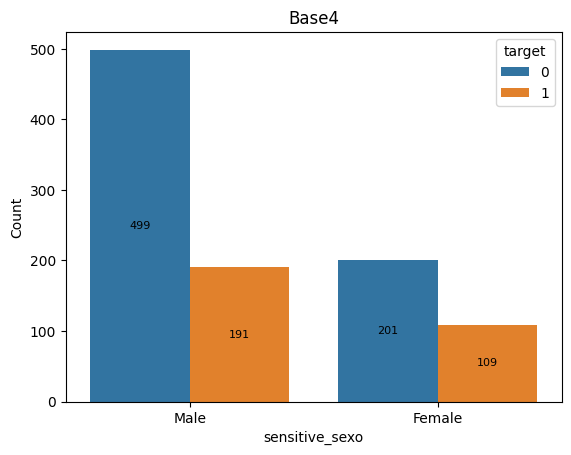

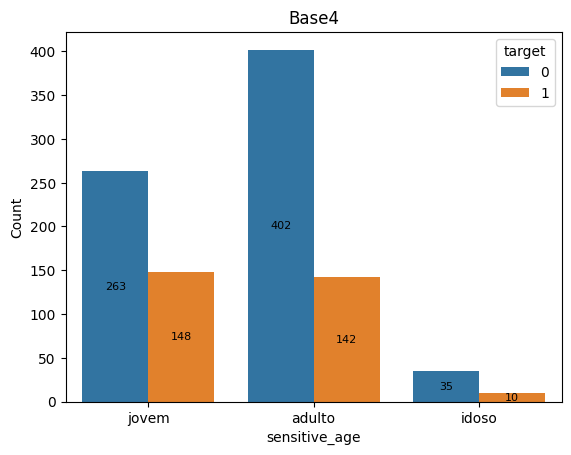

In [7]:
# Configurações de paths
out_age_path = Path("../datasets/processed/base4_age.csv")
out_sexo_path = Path("../datasets/processed/base4_sexo.csv")

# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
x = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets

# Garante que a menor classe é sempre = 1
menor_classe = y.value_counts().idxmin()
target = (y['class'] == menor_classe).astype(int)

# Criar a coluna 'sexo' com base nas categorias de 'Attribute 9'
x['sensitive_sexo'] = x['Attribute9'].map({
    'A91': 1,
    'A92': 0,
    'A93': 1,
    'A94': 1,
    'A95': 0
})

# Definir as faixas de idade
def categorizar_idade(x):
    if x <= 30:
        return "jovem"
    elif x <= 60:
        return "adulto"
    else:
        return "idoso"

# Aplicar a função de criação de faixas
x['sensitive_age'] = x['Attribute13'].apply(categorizar_idade).astype("category")

# Renomear Variaveis ordinais
variaveis_ordinais = ["Attribute8", "Attribute11", "Attribute16", "Attribute18"] 
renomear_dict = {col: f"ordinal_{col}" for col in variaveis_ordinais}
x = x.rename(columns=renomear_dict)

# Excluir variaveis originais de idade e sexo para não causar redundancia
x = x.drop(columns=['Attribute9', 'Attribute13'])

# DATASET ORIGINAL
# Combina x e y para criação de um unico dataset
data = pd.concat([x, target], axis=1)
data = data.rename(columns={target.name: "target"})
classe_counts = data['target'].value_counts()
print("Distribuição original da variável target:\n", classe_counts)

# Shape final
print("Shape:", data.shape)
print("\nColunas:", data.columns.tolist())

listar_variaveis_por_tipo(data)

for col in data.columns:
    analisar_variavel(data, col)

# Salvar
# Versão 1: com sensitive_age, sem sensitive_sexo
data.drop(columns=["sensitive_sexo"], errors="ignore").to_csv(out_age_path, index=False)

# Versão 2: com sensitive_sexo, sem sensitive_age
data.drop(columns=["sensitive_age"], errors="ignore").to_csv(out_sexo_path, index=False)

# Distribuição do target
plot_sex_distribution(data, 'Base4')
plot_age_distribution(data, 'Base4')